<a href="https://colab.research.google.com/github/Riz2693/Dicoding-Submission-FDL/blob/main/Analisis%20Sentimen/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Data Preparation**
- Muhammad Faris Akbar
- Dicoding Analisis Sentimen (Fundamental Deep Learning)

**Load package dan library**

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.5 MB/s eta 0:00:00


In [2]:
import re
import kagglehub
import gensim
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample, class_weight

from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D, GlobalMaxPool1D, GlobalAvgPool1D, concatenate, Input, LayerNormalization, SimpleRNN
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

In [3]:
path = kagglehub.dataset_download("bhimantoros/pretrained-word2vec-indonesia")
print("Path to dataset files:", path)

100%|██████████| 2.97G/2.97G [00:35<00:00, 90.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bhimantoros/pretrained-word2vec-indonesia/versions/1


In [4]:
fix_path = os.path.join(path, "wiki.id.case.model")
print("Path to model file:", fix_path)

Path to model file: /root/.cache/kagglehub/datasets/bhimantoros/pretrained-word2vec-indonesia/versions/1/wiki.id.case.model


**Load dataset sentimen**

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/Riz2693/Dicoding-Submission-FDL/refs/heads/main/Analisis%20Sentimen/dataset_ulasan_playstore.csv')

In [6]:
df.head()

,content,score,soft_clean_content,sentiment_label,confidence_score
0,"suka belanja di shopee,jaya selalu shopee",5,"suka belanja di shopee,jaya selalu shopee",Positif,0.980013
1,Banyak ongkir gratis nya gak akan rugi beli di...,5,Banyak ongkir gratis nya gak akan rugi beli di...,Positif,0.998416
2,saya sangat puas harga nya murah murah,5,saya sangat puas harga nya murah murah,Positif,0.998704
3,belanja jadi mudah dan menyenangkan tak perlu ...,5,belanja jadi mudah dan menyenangkan tak perlu ...,Positif,0.995944
4,kurirnya ga jelas kirim pesan tidak menghubung...,1,kurirnya ga jelas kirim pesan tidak menghubung...,Negatif,0.996652


In [7]:
df.rename(columns={'sentiment_label': 'label'}, inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75184 entries, 0 to 75183
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   content             75184 non-null  object 
 1   score               75184 non-null  int64  
 2   soft_clean_content  75180 non-null  object 
 3   label               75184 non-null  object 
 4   confidence_score    75184 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 2.9+ MB


In [9]:
df.describe(include='all')

,content,score,soft_clean_content,label,confidence_score
count,75184,75184.000000,75180,75184,75184.000000
unique,74442,NaN,73980,3,NaN
top,👍,NaN,👍👍,Positif,NaN
freq,5,NaN,16,38388,NaN
mean,NaN,3.737644,NaN,NaN,0.926488
std,NaN,1.720582,NaN,NaN,0.131151
min,NaN,1.000000,NaN,NaN,0.339691
25%,NaN,2.000000,NaN,NaN,0.933421
50%,NaN,5.000000,NaN,NaN,0.989891
75%,NaN,5.000000,NaN,NaN,0.996888


**Load dataset tambahan**

In [10]:
# df_tambahan_netral = pd.read_csv('https://raw.githubusercontent.com/ArmFriiz/Dicoding-Submission-FDL/refs/heads/main/Analisis%20Sentimen/dataset_ulasan_playstore_netral.csv')

In [11]:
# df_tambahan_netral.info()

In [12]:
# df_tambahan_negatif = pd.read_csv('https://raw.githubusercontent.com/ArmFriiz/Dicoding-Submission-FDL/refs/heads/main/Analisis%20Sentimen/dataset_ulasan_playstore_negatif.csv')

In [13]:
# df_tambahan_negatif.info()

**Gabungkan dataset utama dan tambahan**

In [14]:
# df = pd.concat([main_df, df_tambahan_netral, df_tambahan_negatif]).reset_index(drop=True)

**Drop column score dam confidence score karena hanya digunakan untuk labelling awal saja**

In [15]:
df.drop(columns=['score', 'confidence_score'], inplace=True)

In [16]:
df.columns

Index(['content', 'soft_clean_content', 'label'], dtype='object')

**Cek ulang kondisi data**

In [17]:
df.isna().sum()

,0
content,0
soft_clean_content,4
label,0


In [18]:
df[df.isna().any(axis=1)]

,content,soft_clean_content,label
1251,0baik,NaN,Netral
29229,0ke,NaN,Netral
60584,9or,NaN,Netral
73648,@mantaappp,NaN,Netral


In [19]:
df.dropna(inplace=True)

In [20]:
df.duplicated().sum()

np.int64(742)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.head(5)

,content,soft_clean_content,label
0,"suka belanja di shopee,jaya selalu shopee","suka belanja di shopee,jaya selalu shopee",Positif
1,Banyak ongkir gratis nya gak akan rugi beli di...,Banyak ongkir gratis nya gak akan rugi beli di...,Positif
2,saya sangat puas harga nya murah murah,saya sangat puas harga nya murah murah,Positif
3,belanja jadi mudah dan menyenangkan tak perlu ...,belanja jadi mudah dan menyenangkan tak perlu ...,Positif
4,kurirnya ga jelas kirim pesan tidak menghubung...,kurirnya ga jelas kirim pesan tidak menghubung...,Negatif


In [24]:
df.describe(include='all')

,content,soft_clean_content,label
count,74438,74438,74438
unique,74438,73980,3
top,"Sangat senang belanja di shopee, walaupun ada ...",goodd,Positif
freq,1,12,37986


**Load model normalisasi kata untuk perbaikan kata slank atau typo**

In [25]:
normalization_df = pd.read_csv('https://raw.githubusercontent.com/nasalsabila/kamus-alay/refs/heads/master/colloquial-indonesian-lexicon.csv')

In [26]:
normalization_df.head()

,slang,formal,In-dictionary,context,category1,category2,category3
0,woww,wow,1,wow,elongasi,0,0
1,aminn,amin,1,Selamat ulang tahun kakak tulus semoga panjang...,elongasi,0,0
2,met,selamat,1,Met hari netaas kak!? Wish you all the best @t...,abreviasi,0,0
3,netaas,menetas,1,Met hari netaas kak!? Wish you all the best @t...,afiksasi,elongasi,0
4,keberpa,keberapa,0,Birthday yg keberpa kak?,abreviasi,0,0


In [27]:
normalization_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15006 entries, 0 to 15005
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   slang          15006 non-null  object
 1   formal         15006 non-null  object
 2   In-dictionary  15006 non-null  int64 
 3   context        15006 non-null  object
 4   category1      15006 non-null  object
 5   category2      15006 non-null  object
 6   category3      15006 non-null  object
dtypes: int64(1), object(6)
memory usage: 820.8+ KB


In [28]:
normalization_dict = dict(zip(normalization_df['slang'], normalization_df['formal']))

In [29]:
normalization_dict

{'woww': 'wow',
 'aminn': 'amin',
 'met': 'selamat',
 'netaas': 'menetas',
 'keberpa': 'keberapa',
 'eeeehhhh': 'eh',
 'kata2nyaaa': 'kata-katanya',
 'hallo': 'halo',
 'kaka': 'kakak',
 'ka': 'kak',
 'daah': 'dah',
 'aaaaahhhh': 'ah',
 'yaa': 'ya',
 'smga': 'semoga',
 'slalu': 'selalu',
 'amiin': 'amin',
 'kk': 'kakak',
 'trus': 'terus',
 'sii': 'sih',
 'nyenengin': 'menyenangkan',
 'bgt': 'banget',
 'gemess': 'gemas',
 'akuuu': 'aku',
 'jgn': 'jangan',
 'udah': 'sudah',
 'gitu': 'begitu',
 'aja': 'saja',
 'gemesiin': 'menggemaskan',
 'menyenangkn': 'menyenangkan',
 'rb': 'ribu',
 'akau': 'aku',
 'saranin': 'menyarankan',
 'nemuin': 'menemukan',
 'yah': 'ya',
 'mnis2nya': 'manis-manisnya',
 'gtu': 'begitu',
 'tu': 'itu',
 'idolaa': 'idola',
 'bangett': 'banget',
 'kaakk': 'kak',
 'baaiikkk': 'baik',
 'telaatt': 'telat',
 'kaak': 'kak',
 'yg': 'yang',
 'lg': 'lagi',
 'skarang': 'sekarang',
 'sempet': 'sempat',
 'karna': 'karena',
 'ngga': 'enggak',
 'mantep': 'mantap',
 'loohhh': 'loh',

### **Preprocessing Data**

**Cleaning data (Case folding, Punctuation, Slankword atau typo)**

In [30]:
def cleaning_text(text, normalization_dict):
  text = text.lower() # Ubah teks menjadi huruf kecil

  words = text.split()
  words = [normalization_dict.get(word, word) for word in words]
  text = ' '.join(words)

  text = ''.join([char for char in text if char.isalpha() or char.isspace()])
  text = ' '.join(text.split()) # Bersihkan spasi berlebih di tengah dan di ujung
  return text

In [31]:
df['clean_content'] = df['soft_clean_content'].apply(cleaning_text, normalization_dict=normalization_dict)

In [32]:
df.head()

,content,soft_clean_content,label,clean_content
0,"suka belanja di shopee,jaya selalu shopee","suka belanja di shopee,jaya selalu shopee",Positif,suka belanja di shopeejaya selalu shopee
1,Banyak ongkir gratis nya gak akan rugi beli di...,Banyak ongkir gratis nya gak akan rugi beli di...,Positif,banyak ongkir gratis nya enggak akan rugi beli...
2,saya sangat puas harga nya murah murah,saya sangat puas harga nya murah murah,Positif,saya sangat puas harga nya murah murah
3,belanja jadi mudah dan menyenangkan tak perlu ...,belanja jadi mudah dan menyenangkan tak perlu ...,Positif,belanja jadi mudah dan menyenangkan tak perlu ...
4,kurirnya ga jelas kirim pesan tidak menghubung...,kurirnya ga jelas kirim pesan tidak menghubung...,Negatif,kurirnya enggak jelas kirim pesan tidak menghu...


**Cek jumlah label data dan kata yang terkandung pada data sebelum resample**

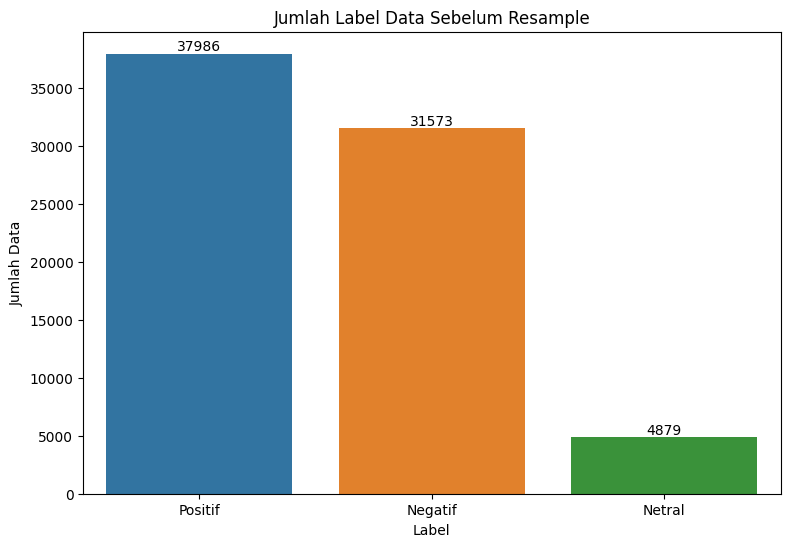

In [33]:
plt.figure(figsize=(9, 6))
sns.barplot(x=df['label'].value_counts().index, y=df['label'].value_counts().values, hue=df['label'].value_counts().index)
plt.title('Jumlah Label Data Sebelum Resample')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.show()

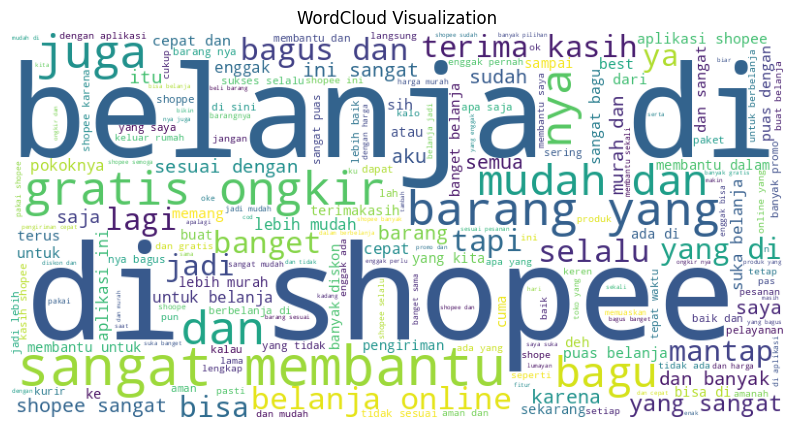

In [34]:
positif_content = df[df['label'] == 'Positif']['clean_content']

all_words = ''.join(positif_content)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(all_words)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('WordCloud Visualization')
plt.show()

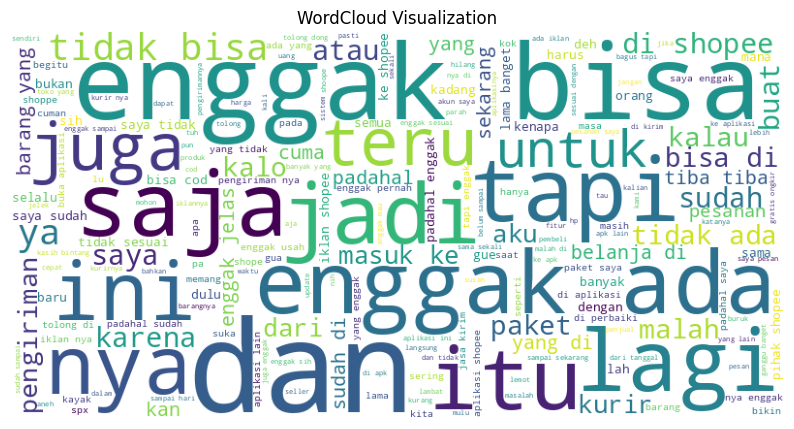

In [35]:
negatif_content = df[df['label'] == 'Negatif']['clean_content']

all_words = ''.join(negatif_content)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(all_words)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('WordCloud Visualization')
plt.show()

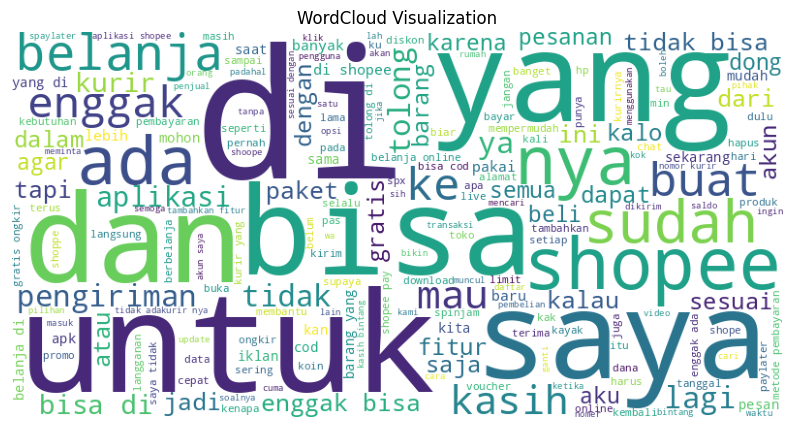

In [36]:
netral_content = df[df['label'] == 'Netral']['clean_content']

all_words = ''.join(netral_content)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(all_words)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('WordCloud Visualization')
plt.show()

**Resample data berdasarkan class rata-rata**

In [37]:
df_negatif = df[df['label'] == 'Negatif']
df_netral = df[df['label'] == 'Netral']
df_positif = df[df['label'] == 'Positif']

n_samples = len(df_positif)

df_netral_upsampling = resample(df_netral, replace=True, n_samples=n_samples, random_state=42)
df_negatif_upsampling = resample(df_negatif, replace=True, n_samples=n_samples, random_state=42)

df_balanced = pd.concat([df_positif, df_negatif_upsampling, df_netral_upsampling])

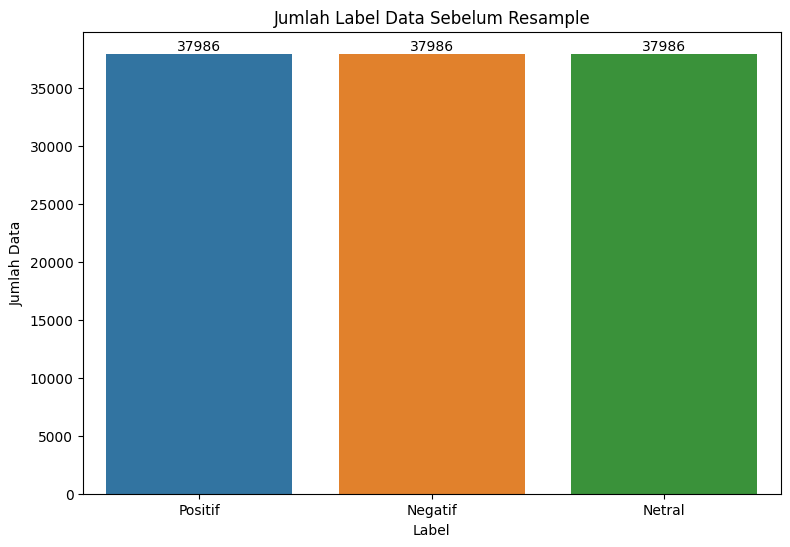

In [38]:
plt.figure(figsize=(9, 6))
sns.barplot(x=df_balanced['label'].value_counts().index, y=df_balanced['label'].value_counts().values, hue=df_balanced['label'].value_counts().index)
plt.title('Jumlah Label Data Sebelum Resample')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.show()

**Encoding label data**

In [39]:
le = LabelEncoder()
df_balanced['label_encoded'] = le.fit_transform(df_balanced['label'])

In [40]:
df_balanced.head()

,content,soft_clean_content,label,clean_content,label_encoded
0,"suka belanja di shopee,jaya selalu shopee","suka belanja di shopee,jaya selalu shopee",Positif,suka belanja di shopeejaya selalu shopee,2
1,Banyak ongkir gratis nya gak akan rugi beli di...,Banyak ongkir gratis nya gak akan rugi beli di...,Positif,banyak ongkir gratis nya enggak akan rugi beli...,2
2,saya sangat puas harga nya murah murah,saya sangat puas harga nya murah murah,Positif,saya sangat puas harga nya murah murah,2
3,belanja jadi mudah dan menyenangkan tak perlu ...,belanja jadi mudah dan menyenangkan tak perlu ...,Positif,belanja jadi mudah dan menyenangkan tak perlu ...,2
5,banyak bonus koin,banyak bonus koin,Positif,banyak bonus koin,2


In [41]:
x = df_balanced['clean_content'].values

In [42]:
print(x)

['suka belanja di shopeejaya selalu shopee'
 'banyak ongkir gratis nya enggak akan rugi beli di sini mah bintang untuk apk ini keren'
 'saya sangat puas harga nya murah murah' ...
 'belanja online ya di shopee saja'
 'buka shope serasa buka game gta di hp' 'sip pokonamah']


In [43]:
y = df_balanced['label_encoded'].values

In [44]:
print(y)
print(le.classes_)

[2 2 2 ... 1 1 1]
['Negatif' 'Netral' 'Positif']


In [45]:
y_onehot = to_categorical(y, num_classes=3)
y_onehot

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]])

**Splitting Data (Training-Testing-Validation) (80-20)**

In [46]:
X_train, X_test, y_train, y_test = train_test_split(x, y_onehot, test_size=0.20, random_state=42, stratify=y)

print(f"Jumlah Data Train : {len(X_train)}")
print(f"Jumlah Data Test  : {len(X_test)}")

Jumlah Data Train : 91166
Jumlah Data Test  : 22792


**Tokenization, sequence dan padding**

In [47]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

lens = [len(s) for s in X_train_seq]
# max_len = int(np.percentile(lens, 95))
max_len = max(lens)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='pre', truncating='pre')
X_test_pad = pad_sequences(X_test_seq,  maxlen=max_len, padding='pre', truncating='pre')

In [48]:
print("Ukuran Sequences : ", max_len)

Ukuran Sequences :  103


### **Model Word2Vec**

**Load model Word2Vec untuk transfer learning (input model)**

In [49]:
w2v_model = gensim.models.Word2Vec.load(fix_path).wv

In [50]:
EMBEDDING_DIM = 400

In [51]:
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

hits = 0
misses = 0

for word, i in word_index.items():
  if word in w2v_model:
    embedding_matrix[i] = w2v_model[word]
    hits += 1
  else:
    misses += 1

print(f"Berhasil: {hits}, Gagal (OOV): {misses}")

Berhasil: 10830, Gagal (OOV): 23253


**Balancing class menggunakan pembobotan**

In [52]:
# y_train_int = np.argmax(y_train, axis=1)

# class_weights_val = class_weight.compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train_int),
#     y=y_train_int
# )
# class_weights_dict = dict(enumerate(class_weights_val))
# print(class_weights_dict)

### **Modelling**

In [53]:
akurasi_model = {}

class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    accuracy = logs.get('accuracy')
    val_accuracy = logs.get('val_accuracy')

    if accuracy is not None and accuracy > 0.94 and val_accuracy > 0.94:
      print("\nAccuracy dan validation_accuracy > 94%. Menghentikan training.")
      self.model.stop_training = True

callback = myCallback()

**Model 1: BI-LSTM + Word Embedding**

In [54]:
inputs = Input(shape=(max_len,))

x = Embedding(input_dim=vocab_size, output_dim=128)(inputs)
x = SpatialDropout1D(0.3)(x)
x = Bidirectional(LSTM(64, dropout=0.2, return_sequences=True))(x)
x = LayerNormalization()(x)

max_pool = GlobalMaxPool1D()(x)
avg_pool = GlobalAvgPool1D()(x)

concatenated = concatenate([max_pool, avg_pool])

x = Dense(32, activation='relu', kernel_regularizer=l2(0.02))(concatenated)
x = Dropout(0.3)(x)

outputs = Dense(3, activation='softmax')(x)

In [55]:
model_1 = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model_1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_1 = model_1.fit(X_train_pad,
            y_train,
            epochs=25,
            batch_size=32,
            validation_data=(X_test_pad, y_test),
            verbose=1,
            callbacks=callback)

Epoch 1/25
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.7279 - loss: 0.8039 - val_accuracy: 0.8826 - val_loss: 0.3318
Epoch 2/25
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 54s 19ms/step - accuracy: 0.8912 - loss: 0.3248 - val_accuracy: 0.8943 - val_loss: 0.3008
Epoch 3/25
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 53s 19ms/step - accuracy: 0.9168 - loss: 0.2538 - val_accuracy: 0.9155 - val_loss: 0.2542
Epoch 4/25
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 54s 19ms/step - accuracy: 0.9274 - loss: 0.2188 - val_accuracy: 0.9196 - val_loss: 0.2519
Epoch 5/25
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 54s 19ms/step - accuracy: 0.9362 - loss: 0.1938 - val_accuracy: 0.9212 - val_loss: 0.2479
Epoch 6/25
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 54s 19ms/step - accuracy: 0.9412 - loss: 0.1759 - val_accuracy: 0.9171 - val_loss: 0.2586
Epoch 7/25
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 54s 19ms/step - accuracy: 0.9466 - loss: 0.1608 - val_accuracy: 0.9310 - val_loss: 0.2366
Epoch 8/25
1246/2849 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.9519 -

In [ ]:
akurasi_model['BI-LSTM + Word Embedding'] = model_1.evaluate(X_test_pad, y_test)[1]

In [ ]:
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

In [ ]:
model_1.save('model_1.h5')

**Model 2: BI-LSTM + Word Embedding + Word2Vec Pre-Trained**

In [ ]:
inputs = Input(shape=(max_len,))

x = Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=False)(inputs)
x = SpatialDropout1D(0.3)(x)
x = Bidirectional(LSTM(64, dropout=0.2, return_sequences=True))(x)
x = LayerNormalization()(x)

max_pool = GlobalMaxPool1D()(x)
avg_pool = GlobalAvgPool1D()(x)

concatenated = concatenate([max_pool, avg_pool])

x = Dense(32, activation='relu', kernel_regularizer=l2(0.02))(concatenated)
x = Dropout(0.3)(x)

outputs = Dense(3, activation='softmax')(x)

In [ ]:
model_2 = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model_2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_2 = model_2.fit(X_train_pad,
            y_train,
            epochs=25,
            batch_size=32,
            validation_data=(X_test_pad, y_test),
            verbose=1,
            callbacks=callback)

In [ ]:
akurasi_model['BI-LSTM + Word Embedding + Word2Vec Pre-Trained'] = model_2.evaluate(X_test_pad, y_test)[1]

In [ ]:
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

In [ ]:
model_2.save('model_2.h5')

**Model 3: RNN + Word Embedding**

In [ ]:
inputs = Input(shape=(max_len,))

x = Embedding(input_dim=vocab_size, output_dim=128)(inputs)
x = SpatialDropout1D(0.3)(x)
x = SimpleRNN(64, dropout=0.2, return_sequences=True)(x)
x = LayerNormalization()(x)

max_pool = GlobalMaxPool1D()(x)
avg_pool = GlobalAvgPool1D()(x)

concatenated = concatenate([max_pool, avg_pool])

x = Dense(32, activation='relu', kernel_regularizer=l2(0.02))(concatenated)
x = Dropout(0.3)(x)

outputs = Dense(3, activation='softmax')(x)

In [ ]:
model_3 = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model_3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_3 = model_3.fit(X_train_pad,
            y_train,
            epochs=25,
            batch_size=32,
            validation_data=(X_test_pad, y_test),
            verbose=1,
            callbacks=callback)

In [ ]:
akurasi_model['RNN + Word Embedding'] = model_3.evaluate(X_test_pad, y_test)[1]

In [ ]:
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

In [ ]:
model_3.save('model_3.h5')

**Model 4: RNN + Word Embedding + Word2Vec Pre-Trained**

In [ ]:
inputs = Input(shape=(max_len,))

x = Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=False)(inputs)
x = SpatialDropout1D(0.3)(x)
x = SimpleRNN(64, dropout=0.2, return_sequences=True)(x)
x = LayerNormalization()(x)

max_pool = GlobalMaxPool1D()(x)
avg_pool = GlobalAvgPool1D()(x)

concatenated = concatenate([max_pool, avg_pool])

x = Dense(32, activation='relu', kernel_regularizer=l2(0.02))(concatenated)
x = Dropout(0.3)(x)

outputs = Dense(3, activation='softmax')(x)

In [ ]:
model_4 = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model_4.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_4 = model_4.fit(X_train_pad,
            y_train,
            epochs=25,
            batch_size=32,
            validation_data=(X_test_pad, y_test),
            verbose=1,
            callbacks=callback)

In [ ]:
akurasi_model['RNN + Word Embedding + Word2Vec Pre-Trained'] = model_4.evaluate(X_test_pad, y_test)[1]

In [ ]:
plt.plot(history_4.history['loss'])
plt.plot(history_4.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

In [ ]:
model_4.save('model_4.h5')

**Model 5: Logistic Regression + Word2Vec Pre-Trained (Average Weight)**

In [ ]:
def get_avg_vector(text_list, model, dim):
  vecs = []
  for text in text_list:
    words = text.split()
    vector_sum = np.zeros((dim,), dtype="float32")
    n_words = 0

    for w in words:
      if w in model:
        vector_sum = np.add(vector_sum, model[w])
        n_words += 1

    if n_words > 0:
      vector_sum = np.divide(vector_sum, n_words)

    vecs.append(vector_sum)
  return np.array(vecs)

In [ ]:
X_train_w2v = get_avg_vector(X_train, w2v_model, EMBEDDING_DIM)
X_test_w2v = get_avg_vector(X_test, w2v_model, EMBEDDING_DIM)
y_label_init = np.argmax(y_train, axis=1)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_w2v, y_label_init)

In [ ]:
y_pred_3 = clf.predict(X_test_w2v)
acc = accuracy_score(np.argmax(y_test, axis=1), y_pred_3)

print(f"Akurasi: {acc*100:.2f}%")
print(classification_report(np.argmax(y_test, axis=1), y_pred_3))

In [ ]:
akurasi_model['Logistic Regression + Word2Vec Pre-Trained (Average Weight)'] = acc

In [ ]:
with open('model_5.pkl', 'wb') as f:
  pickle.dump(clf, f)

### **Akumulasi Akurasi Model**

In [ ]:
count = 1
for key, value in akurasi_model.items():
  print(f"{count}. {key}: {value*100:.2f}%")
  count+=1

### **Test Prediksi Model**

In [ ]:
teks = "barang nya hancur banget, nyesel beli disini!!!"

In [ ]:
text_cleaned = cleaning_text(teks, normalization_dict)

text_seq = tokenizer.texts_to_sequences([text_cleaned])

text_padded = pad_sequences(text_seq, maxlen=max_len, padding='pre', truncating='pre')

In [ ]:
teks_2 = "barang nya bagus, pengiriman cepat"

In [ ]:
text_cleaned_2 = cleaning_text(teks_2, normalization_dict)

text_seq_2 = tokenizer.texts_to_sequences([text_cleaned_2])

text_padded_2 = pad_sequences(text_seq_2, maxlen=max_len, padding='pre', truncating='pre')

**Model 1**

In [ ]:
prediction_prob = model_1.predict(text_padded)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

In [ ]:
prediction_prob = model_1.predict(text_padded_2)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks_2}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

**Model 2**

In [ ]:
prediction_prob = model_2.predict(text_padded)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

In [ ]:
prediction_prob = model_2.predict(text_padded_2)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks_2}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

**Model 3**

In [ ]:
prediction_prob = model_3.predict(text_padded)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

In [ ]:
prediction_prob = model_3.predict(text_padded_2)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks_2}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

**Model 4**

In [ ]:
prediction_prob = model_4.predict(text_padded)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

In [ ]:
prediction_prob = model_4.predict(text_padded_2)
prediction_index = np.argmax(prediction_prob)
confidence = np.max(prediction_prob) * 100
final_label = le.inverse_transform([prediction_index])[0]

print(f"Teks: {teks_2}")
print(f"Label prediksi: {final_label}")
print(f"Confidence: {confidence:.2f}%")

**Model 5**

In [ ]:
text_w2v = get_avg_vector([text_cleaned], w2v_model, EMBEDDING_DIM)
prediction_index_3 = clf.predict(text_w2v)[0]
final_label_3 = le.inverse_transform([prediction_index_3])[0]

print(f"Teks: {teks}")
print(f"Label prediksi: {final_label_3}")

In [ ]:
text_w2v = get_avg_vector([text_cleaned_2], w2v_model, EMBEDDING_DIM)
prediction_index_3 = clf.predict(text_w2v)[0]
final_label_3 = le.inverse_transform([prediction_index_3])[0]

print(f"Teks: {teks_2}")
print(f"Label prediksi: {final_label_3}")

**Load requirements.txt**

In [ ]:
# !pip freeze > requirements.txt